# <center> Booking reviews

## <center> Problem statement

One of the company's problems is dishonest hotels that inflate their ratings. One way to find such hotels is to build a model that predicts the hotel's rating. If the model's predictions differ greatly from the actual result, then the hotel may be cheating and should be checked.

## <center> Data introduction

* hotel_address
* review_date - the date of review posting
* average_score 
* hotel_name
* reviewer_nationality
* negative_review 
* review_total_negative_word_counts 
* positive_review 
* review_total_positive_word_counts
* reviewer_score
* total_number_of_reviews_reviewer_has_given 
* total_number_of_reviews 
* tags 
* days_since_review  
* additional_number_of_scoring - есть также некоторые гости, которые просто поставили оценку сервису, а не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* lat - latitude
* lng - longitude 

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# import tools for data split:
from sklearn.model_selection import train_test_split

# import library for cotegorical codind
import category_encoders as ce
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sf-booking/hotels_test.csv
/kaggle/input/sf-booking/hotels_train.csv
/kaggle/input/sf-booking/submission.csv
/kaggle/input/data-filled/filled_data.cvs
/kaggle/input/vader-lexicon/vader_lexicon.txt


In [3]:
# всегда фиксируйте RANDOM_SEED, чтобы ваши эксперименты были воспроизводимы!
RANDOM_SEED = 42

In [4]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

In [5]:
# Подгрузим наши данные из соревнования

DATA_DIR = '/kaggle/input/sf-booking/'
df_train = pd.read_csv(DATA_DIR+'/hotels_train.csv') # датасет для обучения
df_test = pd.read_csv(DATA_DIR+'hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv(DATA_DIR+'/submission.csv') # самбмишн

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [7]:
df_train.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [9]:
df_test.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443


In [6]:
sample_submission.head(2)

,reviewer_score,id
0,1,488440
1,10,274649


In [7]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


In [8]:
# ВАЖНО! дря корректной обработки признаков объединяем трейн и тест в один датасет
df_train['sample'] = 1 # помечаем где у нас трейн
df_test['sample'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = 0 # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями

data = df_test.append(df_train, sort=False).reset_index(drop=True) # объединяем

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515738 non-null  object 
 1   additional_number_of_scoring                515738 non-null  int64  
 2   review_date                                 515738 non-null  object 
 3   average_score                               515738 non-null  float64
 4   hotel_name                                  515738 non-null  object 
 5   reviewer_nationality                        515738 non-null  object 
 6   negative_review                             515738 non-null  object 
 7   review_total_negative_word_counts           515738 non-null  int64  
 8   total_number_of_reviews                     515738 non-null  int64  
 9   positive_review                             515738 non-null  object 
 

In [ ]:
#data['lat'] = data['lat'].fillna(0, inplace=True)
#data['lng'] = data['lng'].fillna(0, inplace=True)
#data = data.dropna(how='any', axis=0)

#data['lat'] = data['lat'].apply(lambda x: round(x,2))
#data['lng'] = data['lng'].apply(lambda x: round(x,2))
#len(data['lat'].unique())


In [10]:
data.nunique(dropna=False)

hotel_address                                   1493
additional_number_of_scoring                     480
review_date                                      731
average_score                                     34
hotel_name                                      1492
reviewer_nationality                             227
negative_review                               330011
review_total_negative_word_counts                402
total_number_of_reviews                         1142
positive_review                               412601
review_total_positive_word_counts                365
total_number_of_reviews_reviewer_has_given       198
tags                                           55242
days_since_review                                731
lat                                             1473
lng                                             1473
sample                                             2
reviewer_score                                    38
dtype: int64

## 1. Cleaning data from missing values.

In [11]:
# import data for missing geo values 
new_data = pd.read_csv("/kaggle/input/data-filled/filled_data.cvs")

# create dictionaries for input
lat_dict = dict(zip(new_data['hotel_name'], new_data['lat']))
lng_dict = dict(zip(new_data['hotel_name'], new_data['lng']))

# fill missing valeus in
data['lat'] = data['lat'].fillna(data['hotel_name'].map(lat_dict))
data['lng'] = data['lng'].fillna(data['hotel_name'].map(lng_dict))

In [9]:
# fill-missing check 
display(data.isnull().mean() * 100)

hotel_address                                 0.0
additional_number_of_scoring                  0.0
review_date                                   0.0
average_score                                 0.0
hotel_name                                    0.0
reviewer_nationality                          0.0
negative_review                               0.0
review_total_negative_word_counts             0.0
total_number_of_reviews                       0.0
positive_review                               0.0
review_total_positive_word_counts             0.0
total_number_of_reviews_reviewer_has_given    0.0
tags                                          0.0
days_since_review                             0.0
lat                                           0.0
lng                                           0.0
sample                                        0.0
reviewer_score                                0.0
dtype: float64

##  2. Feature engineering.

In [12]:
# Выделяем из названия отеля страну

def country_func(adr):
             """
    Function celect country of hotel

    param:
    
    - text_columns: hotel address
    
    return:
    - country of hotel
    """
    adr = adr.split(' ')
    count = adr[-1]
    if count == 'Kingdom':
        return 'United'+' ' + count
    else:
        return count

#print(country_func('97 Cromwell Road Kensington and Chelsea London SW7 4DN United Kingdom'))

data['hotel_country'] = data['hotel_address'].apply(country_func)
data['hotel_country'].describe()

count             515738
unique                 6
top       United Kingdom
freq              262301
Name: hotel_country, dtype: object

In [14]:
# make review_date to datetime format
data['review_date'] = pd.to_datetime(data['review_date'])

# creating new feature 'year'
data['year'] = data['review_date'].dt.year

# creating new feature 'month'
data['month'] = data['review_date'].dt.month

# creating new feature 'day of week'
data['day_of_week'] = data['review_date'].dt.dayofweek

# new features check
data[['day_of_week', 'month', 'year', 'review_date' ]].head(2)

,day_of_week,month,year,review_date
0,4,7,2017,2017-07-21
1,0,12,2016,2016-12-12


In [15]:

# creating the season feature


def season_func(col):
          """
    Function add season sign

    param:
    
    - date_columns: month
    
    return:
    - name of season
    """
    if col in (3, 4, 5):
        return 'spring'
    elif col in (1, 2, 12):
        return 'winter'
    elif col in (9, 10, 11):
        return 'autumn'
    else:
        return 'summer'

data['season'] = data['month'].apply(season_func)

In [17]:
# tags splitting function

def rev_func(num_tags):
          """
    Function split text tag into separate words

    param:
    
    - text_columns: tags text
    
    return:
    - part of text: list of words tag
    """

    num_tags = num_tags[2:-2]
    res = num_tags.strip().split(' \', \' ')
    return res
# apply function
data['tags_n'] = data['tags'].apply(rev_func)

# strings splitting
explode_tags = data['tags_n'].explode()





display(data['tags_n'])

0         [Leisure trip, Couple, Double Room, Stayed 2 n...
1         [Leisure trip, Group, Triple Room, Stayed 1 ni...
2         [Business trip, Solo traveler, Twin Room, Stay...
3         [Leisure trip, Couple, Ambassador Junior Suite...
4         [Business trip, Solo traveler, Classic Double ...
                                ...                        
515733    [Leisure trip, Group, Club Double or Twin Room...
515734    [Leisure trip, Couple, Standard Double Room, S...
515735    [Business trip, Solo traveler, Single Room, St...
515736    [Leisure trip, Solo traveler, Deluxe Double Ro...
515737    [Leisure trip, Couple, Bunk Bed Room, Stayed 4...
Name: tags_n, Length: 515738, dtype: object

In [17]:
display(data['tags_n'][0])

['Leisure trip', 'Couple', 'Double Room', 'Stayed 2 nights']

In [18]:
# extracting stayed nights number fuction

def find_stayed(row):
          """
    Function celect in text tag quantity of stayed nights

    param:
    
    - text_columns: tags text
    
    return:
    - part of text: number of nights
    """
    
    for tag in row:
        if 'Stayed' in tag:
            return tag.split()[1]
    return None

data['night_quant'] = data['tags_n'].apply(find_stayed)

display(data[['tags_n', 'night_quant']])

,tags_n,night_quant
0,"[Leisure trip, Couple, Double Room, Stayed 2 n...",2
1,"[Leisure trip, Group, Triple Room, Stayed 1 ni...",1
2,"[Business trip, Solo traveler, Twin Room, Stay...",1
3,"[Leisure trip, Couple, Ambassador Junior Suite...",1
4,"[Business trip, Solo traveler, Classic Double ...",2
...,...,...
515733,"[Leisure trip, Group, Club Double or Twin Room...",2
515734,"[Leisure trip, Couple, Standard Double Room, S...",4
515735,"[Business trip, Solo traveler, Single Room, St...",1
515736,"[Leisure trip, Solo traveler, Deluxe Double Ro...",2


In [19]:
# extracting type of trip function

def type_trip(lst):
          """
    Function celect in text tag type of trip

    param:
    
    - text_columns: tags text
    
    return:
    - part of text: type of trip
    """
    
    if isinstance(lst, list) and len(lst) > 0:  # Проверяем, что это список и он не пуст
        return lst[0]
    return None

data['type_of_trip'] = data['tags_n'].apply(type_trip)

# extracting type of room function

def type_room(lst):
          """
    Function celect in text tag type of room

    param:
    
    - text_columns: tags text
    
    return:
    - part of text: type of room
    """
    if isinstance(lst, list) and len(lst) > 2:  # Проверяем, что в списке есть хотя бы 2 элемента
        return lst[2]
    return None

data['type_of_room'] = data['tags_n'].apply(type_room)

display(data['type_of_room'].describe())

count          515647
unique           2412
top       Double Room
freq            34027
Name: type_of_room, dtype: object

In [20]:
# extracting type of guest function

def type_guest(lst):
        """
    Function celect in text tag type of guest

    param:
    
    - text_columns: tags text
    
    return:
    - part of text: type of guest
    """
    if isinstance(lst, list) and len(lst) > 1:  # Проверяем, что в списке есть хотя бы 2 элемента
        return lst[1]
    return None

data['type_of_guest'] = data['tags_n'].apply(type_guest)

In [22]:
data['type_of_guest'].describe()

count     515732
unique      1025
top       Couple
freq      245788
Name: type_of_guest, dtype: object

In [23]:
display(data.isnull().mean() * 100)

hotel_address                                 0.000000
additional_number_of_scoring                  0.000000
review_date                                   0.000000
average_score                                 0.000000
hotel_name                                    0.000000
reviewer_nationality                          0.000000
negative_review                               0.000000
review_total_negative_word_counts             0.000000
total_number_of_reviews                       0.000000
positive_review                               0.000000
review_total_positive_word_counts             0.000000
total_number_of_reviews_reviewer_has_given    0.000000
tags                                          0.000000
days_since_review                             0.000000
lat                                           0.000000
lng                                           0.000000
sample                                        0.000000
reviewer_score                                0.000000
hotel_coun

In [31]:
data['type_of_room'].describe()

count          515647
unique           2412
top       Double Room
freq            34027
Name: type_of_room, dtype: object

In [21]:
# fill in empty values in 'night_quant' and 'type_of_room'

data['night_quant'] = pd.to_numeric(data['night_quant'], errors='coerce')
data['night_quant'] = data['night_quant'].fillna(round(data['night_quant'].mean()))

data['type_of_room'] = data['type_of_room'].fillna(str(data['type_of_room'].mode()[0]))
data['type_of_guest'] = data['type_of_guest'].fillna(str(data['type_of_guest'].mode()[0]))


In [22]:
display(data.isnull().mean() * 100)

hotel_address                                 0.0
additional_number_of_scoring                  0.0
review_date                                   0.0
average_score                                 0.0
hotel_name                                    0.0
reviewer_nationality                          0.0
negative_review                               0.0
review_total_negative_word_counts             0.0
total_number_of_reviews                       0.0
positive_review                               0.0
review_total_positive_word_counts             0.0
total_number_of_reviews_reviewer_has_given    0.0
tags                                          0.0
days_since_review                             0.0
lat                                           0.0
lng                                           0.0
sample                                        0.0
reviewer_score                                0.0
hotel_country                                 0.0
year                                          0.0


## 3. Encoding categorical features.

In [23]:
# encoding hotel country feature by OneHotEconder
encoder = ce.OneHotEncoder(cols=['hotel_country'], use_cat_names=True) 
type_bin = encoder.fit_transform(data['hotel_country'])
data = pd.concat([data, type_bin], axis=1)

In [24]:
# encoding season feature  by OneHotEconder

encoder = ce.OneHotEncoder(cols=['season'], use_cat_names=True) 
type_bin = encoder.fit_transform(data['season'])
data = pd.concat([data, type_bin], axis=1)

In [26]:
# encoding type_of_trip feature  by OneHotEconder
encoder = ce.OneHotEncoder(cols=['type_of_trip'], use_cat_names=True) 
type_bin = encoder.fit_transform(data['type_of_trip'])
data = pd.concat([data, type_bin], axis=1)


In [27]:
# encoding categorical feature country of reviewer
import category_encoders as ce
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality']) # указываем столбец для кодирования
reviewer_country_bin = bin_encoder.fit_transform(data['reviewer_nationality'])
data = pd.concat([data, reviewer_country_bin], axis=1)

In [28]:
# encoding categorical feature type of room
bin_encoder = ce.BinaryEncoder(cols=['type_of_room']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(data['type_of_room'])
data = pd.concat([data, type_bin], axis=1)

In [29]:
# encoding categorical featur type of guest
bin_encoder = ce.BinaryEncoder(cols=['type_of_guest']) 
type_bin = bin_encoder.fit_transform(data['type_of_guest'])
data = pd.concat([data, type_bin], axis=1)

In [30]:
# encoding categorical featur type of trip
label_encoder = LabelEncoder()
data['night_st'] =  label_encoder.fit_transform(data['night_quant'])


## 4.Analyzing text reviews

In [34]:
# install a tool for text analyzing
!pip install nltk
import nltk


In [35]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.data.path.append("/kaggle/input/vader-lexicon")

In [36]:
# creating an analyzer object.
sent_analyzer = SentimentIntensityAnalyzer()


def set_metric_func(df, review_col):
    """
    Function add sentiment metrics for text coloums 

    param:
    
    - df: pandas.DataFrame
    - text_columns: list[str] — review coloums
    
    return:
    - df with new fetuares : 'neg', 'neu', 'pos', 'compound'
    """
    sia = SentimentIntensityAnalyzer()
    
    for col in review_col:
        sentiment_scores = df[col].fillna("").apply(sia.polarity_scores)
        sentiment_df = sentiment_scores.apply(pd.Series)
        sentiment_df.columns = [f"{c}_{col}" for c in sentiment_df.columns] 
        df = pd.concat([df, sentiment_df], axis=1)
        
        return df

In [37]:
# apply function to reviews coloums
data = set_metric_func(data, ['negative_review'])
data = set_metric_func(data, ['positive_review'])

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 87 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               515738 non-null  object        
 1   additional_number_of_scoring                515738 non-null  int64         
 2   review_date                                 515738 non-null  datetime64[ns]
 3   average_score                               515738 non-null  float64       
 4   hotel_name                                  515738 non-null  object        
 5   reviewer_nationality                        515738 non-null  object        
 6   negative_review                             515738 non-null  object        
 7   review_total_negative_word_counts           515738 non-null  int64         
 8   total_number_of_reviews                     515738 non-null  int64        

## 5. Multicollinearity analysis

In [72]:
df = data.copy()
#df = df.drop(['hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 'negative_review ', 'positive_review', 'tags ', 'days_since_review',  ])

In [73]:
def obj_del_func(df):
    # Выбираем колонки типа object
    object_cols = df.select_dtypes(include='object').columns
    # Удаляем их
    return df.drop(columns=object_cols)
        

In [ ]:
df_cleaned = obj_del_func(df)
df_cleaned =  df_cleaned.drop('review_date', axis=1)

In [58]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 73 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515738 non-null  int64  
 1   average_score                               515738 non-null  float64
 2   review_total_negative_word_counts           515738 non-null  int64  
 3   total_number_of_reviews                     515738 non-null  int64  
 4   review_total_positive_word_counts           515738 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  515738 non-null  int64  
 6   lat                                         515738 non-null  float64
 7   lng                                         515738 non-null  float64
 8   sample                                      515738 non-null  int64  
 9   reviewer_score                              515738 non-null  float64
 

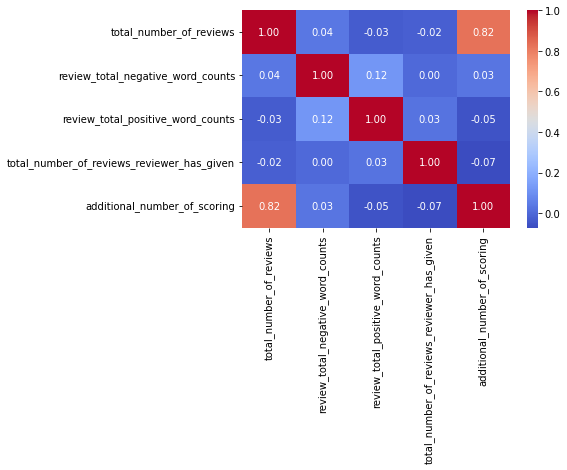

In [42]:
# correlation of numeric featues


numeric_data = df_cleand[['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'additional_number_of_scoring']]
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.show()

<AxesSubplot:>

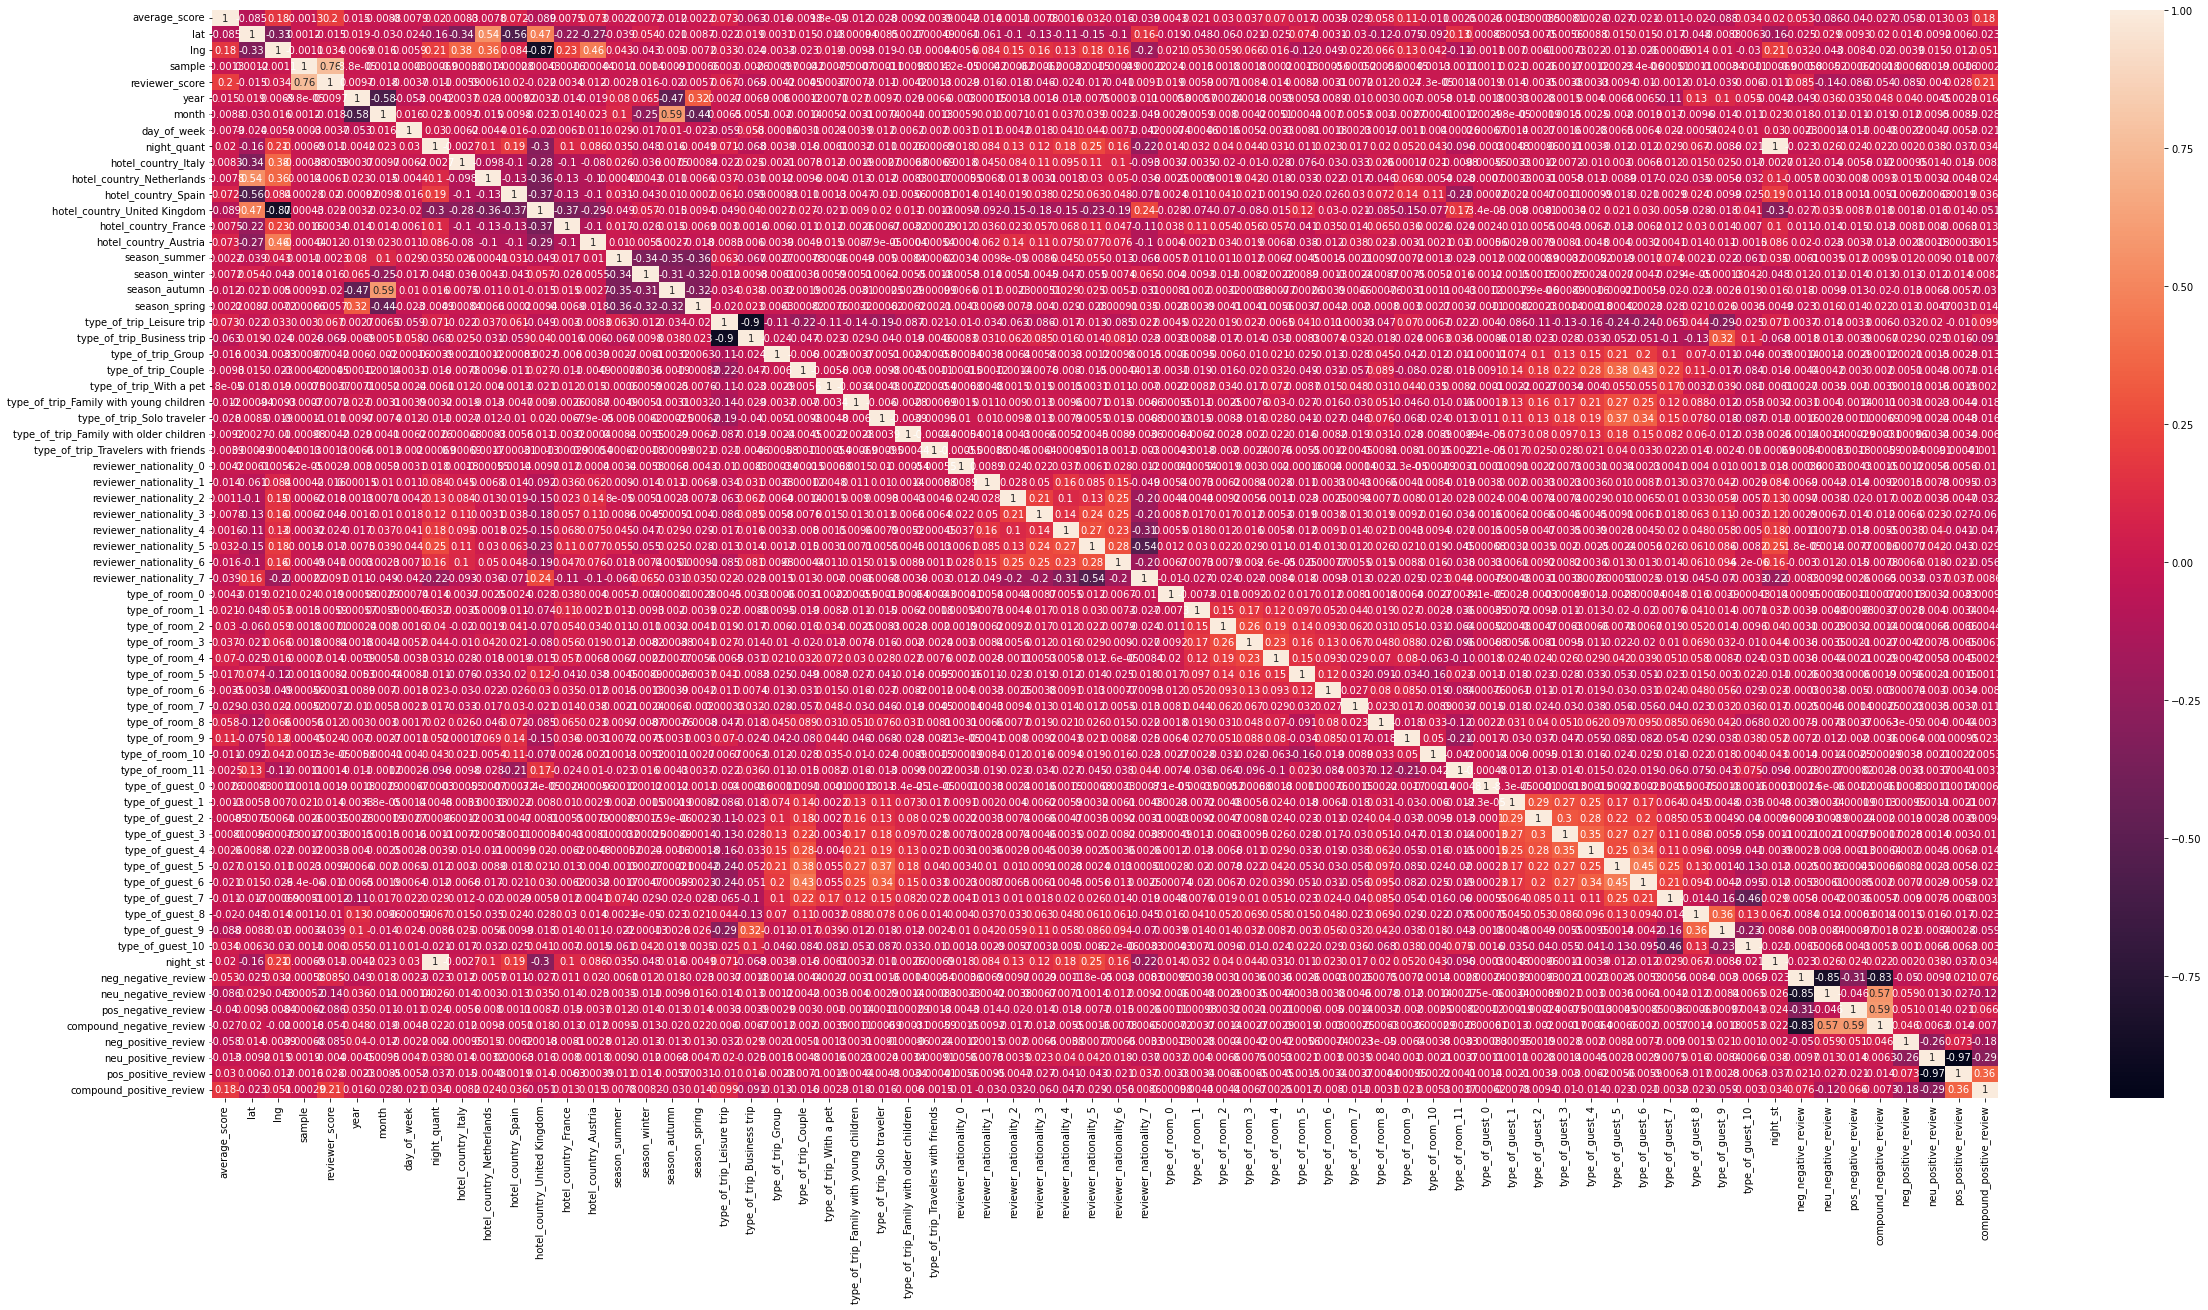

In [43]:
# correlation of categorial featues


plt.rcParams['figure.figsize'] = (40,20)
cat_data = df_cleand.drop(['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'additional_number_of_scoring', 'review_date'], axis=1)
sns.heatmap(cat_data.corr(method='spearman'), annot=True)


Features  high correlation:

* neu_positive_review and pos_posetive_review have
* neg_negative_review and neu_negative_review
* neg_negative_review and compound_negative_review
* type_of_trip_Buisness_trip and type_of_trip_Leisure_trip
* lng and hotel_country_United_Kindom

So we need to delete one of the pair

## 6. Selecting features based on their importance

In [44]:
# Split dataframe 
# Х - features of hotel, у - target variable  
X = df_cleand.drop(['reviewer_score', 'review_date', 'sample'], axis = 1)  
y = df_cleand['reviewer_score'] 


# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split 

# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### 6.1. ANOVA -test for numerical features

<AxesSubplot:>

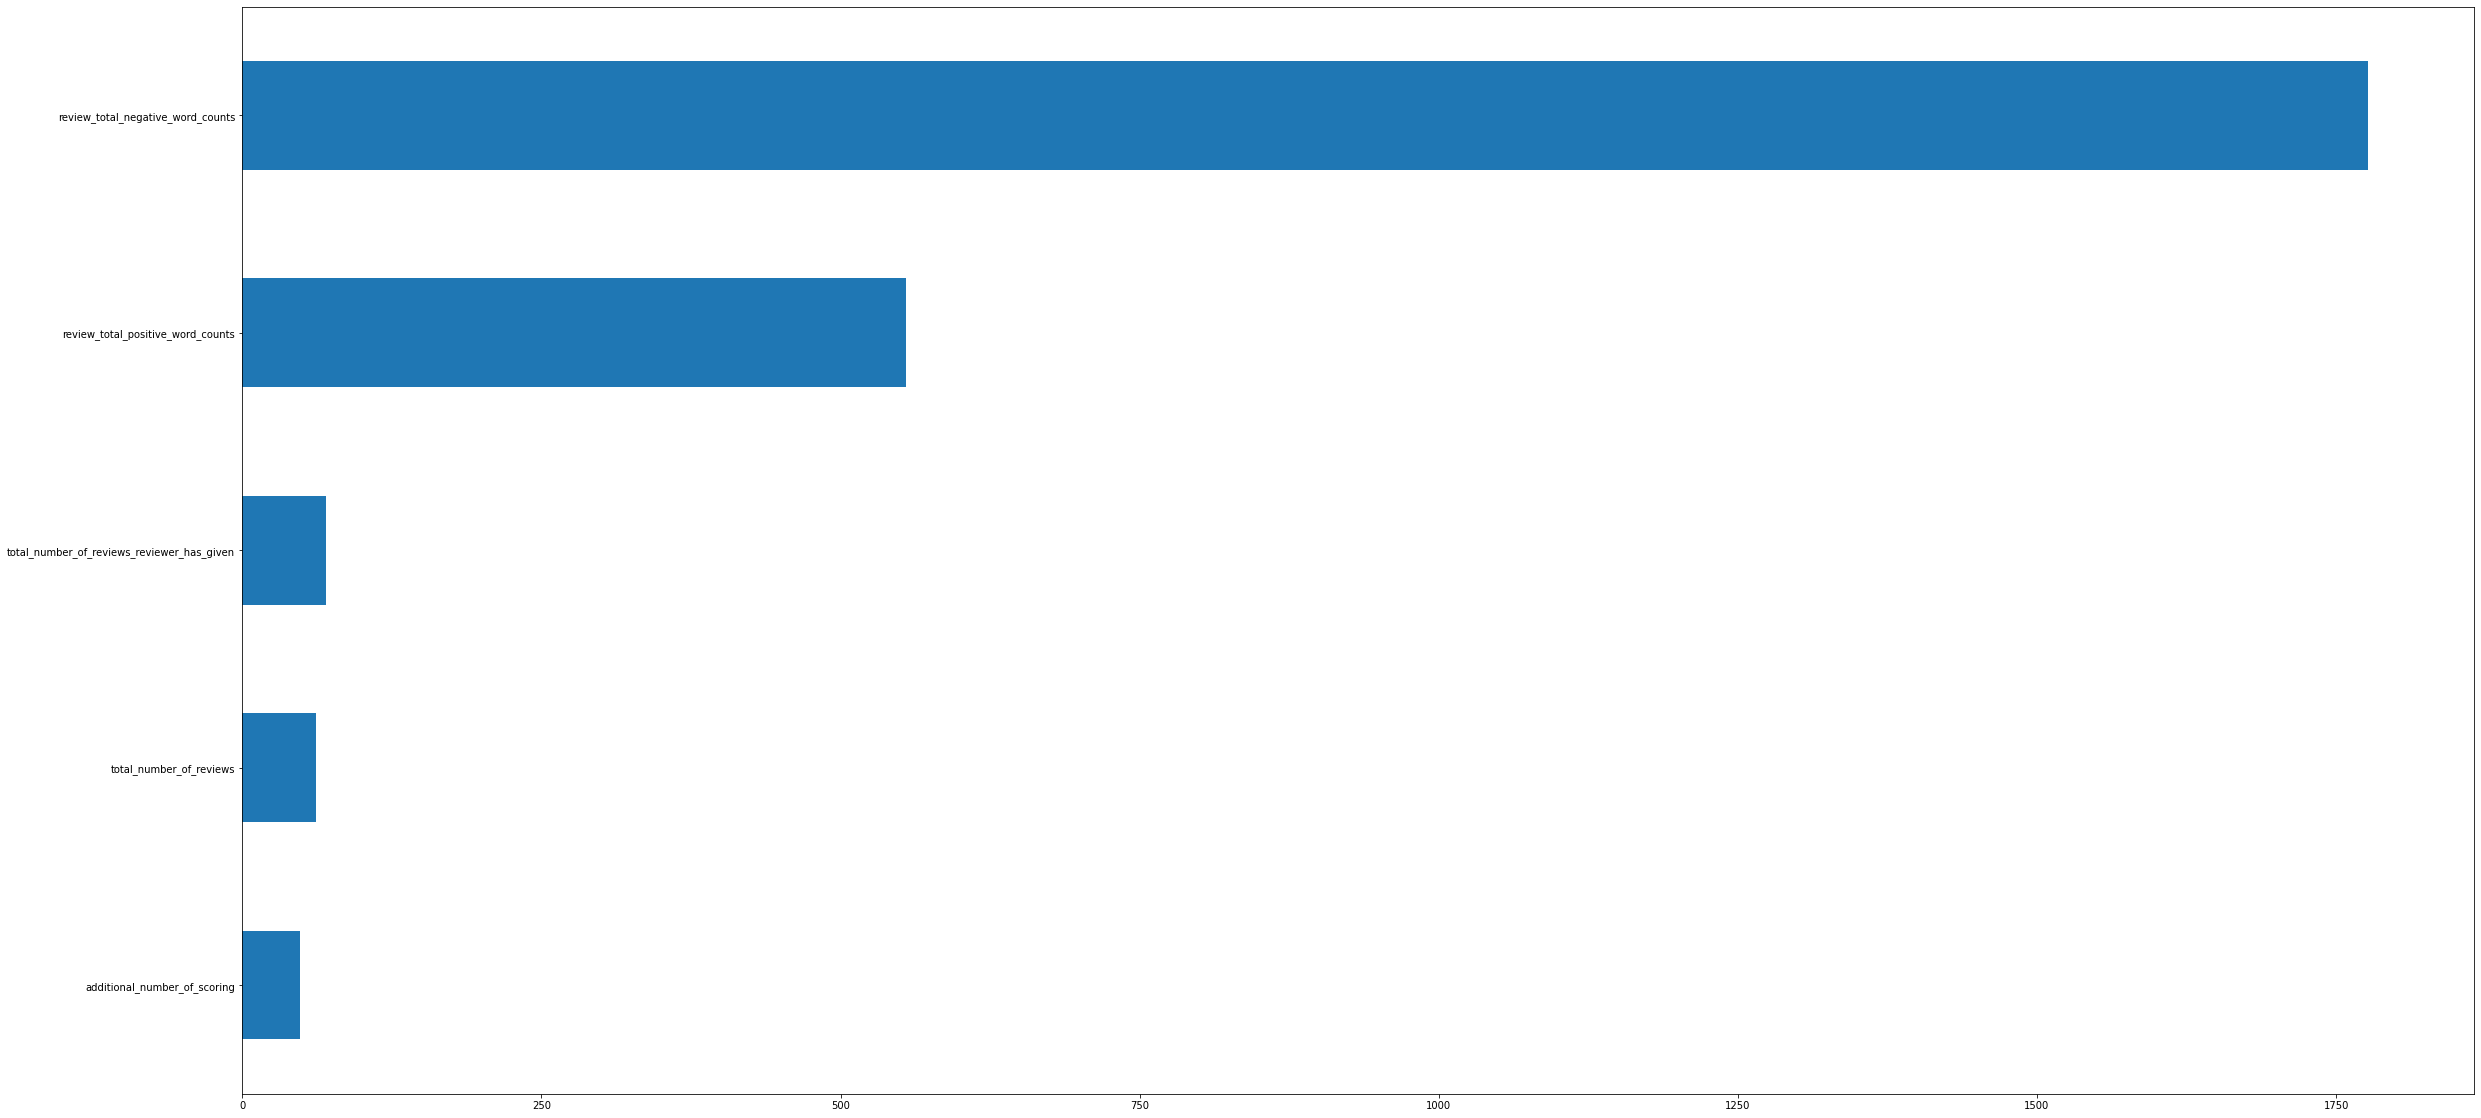

In [35]:
from sklearn.feature_selection import f_classif # anova
num_col = ['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'additional_number_of_scoring']
imp_num = pd.Series(f_classif(X[num_col], y)[0], index = num_col)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

### 6.2 Chi-squared test for categorical features

<AxesSubplot:>

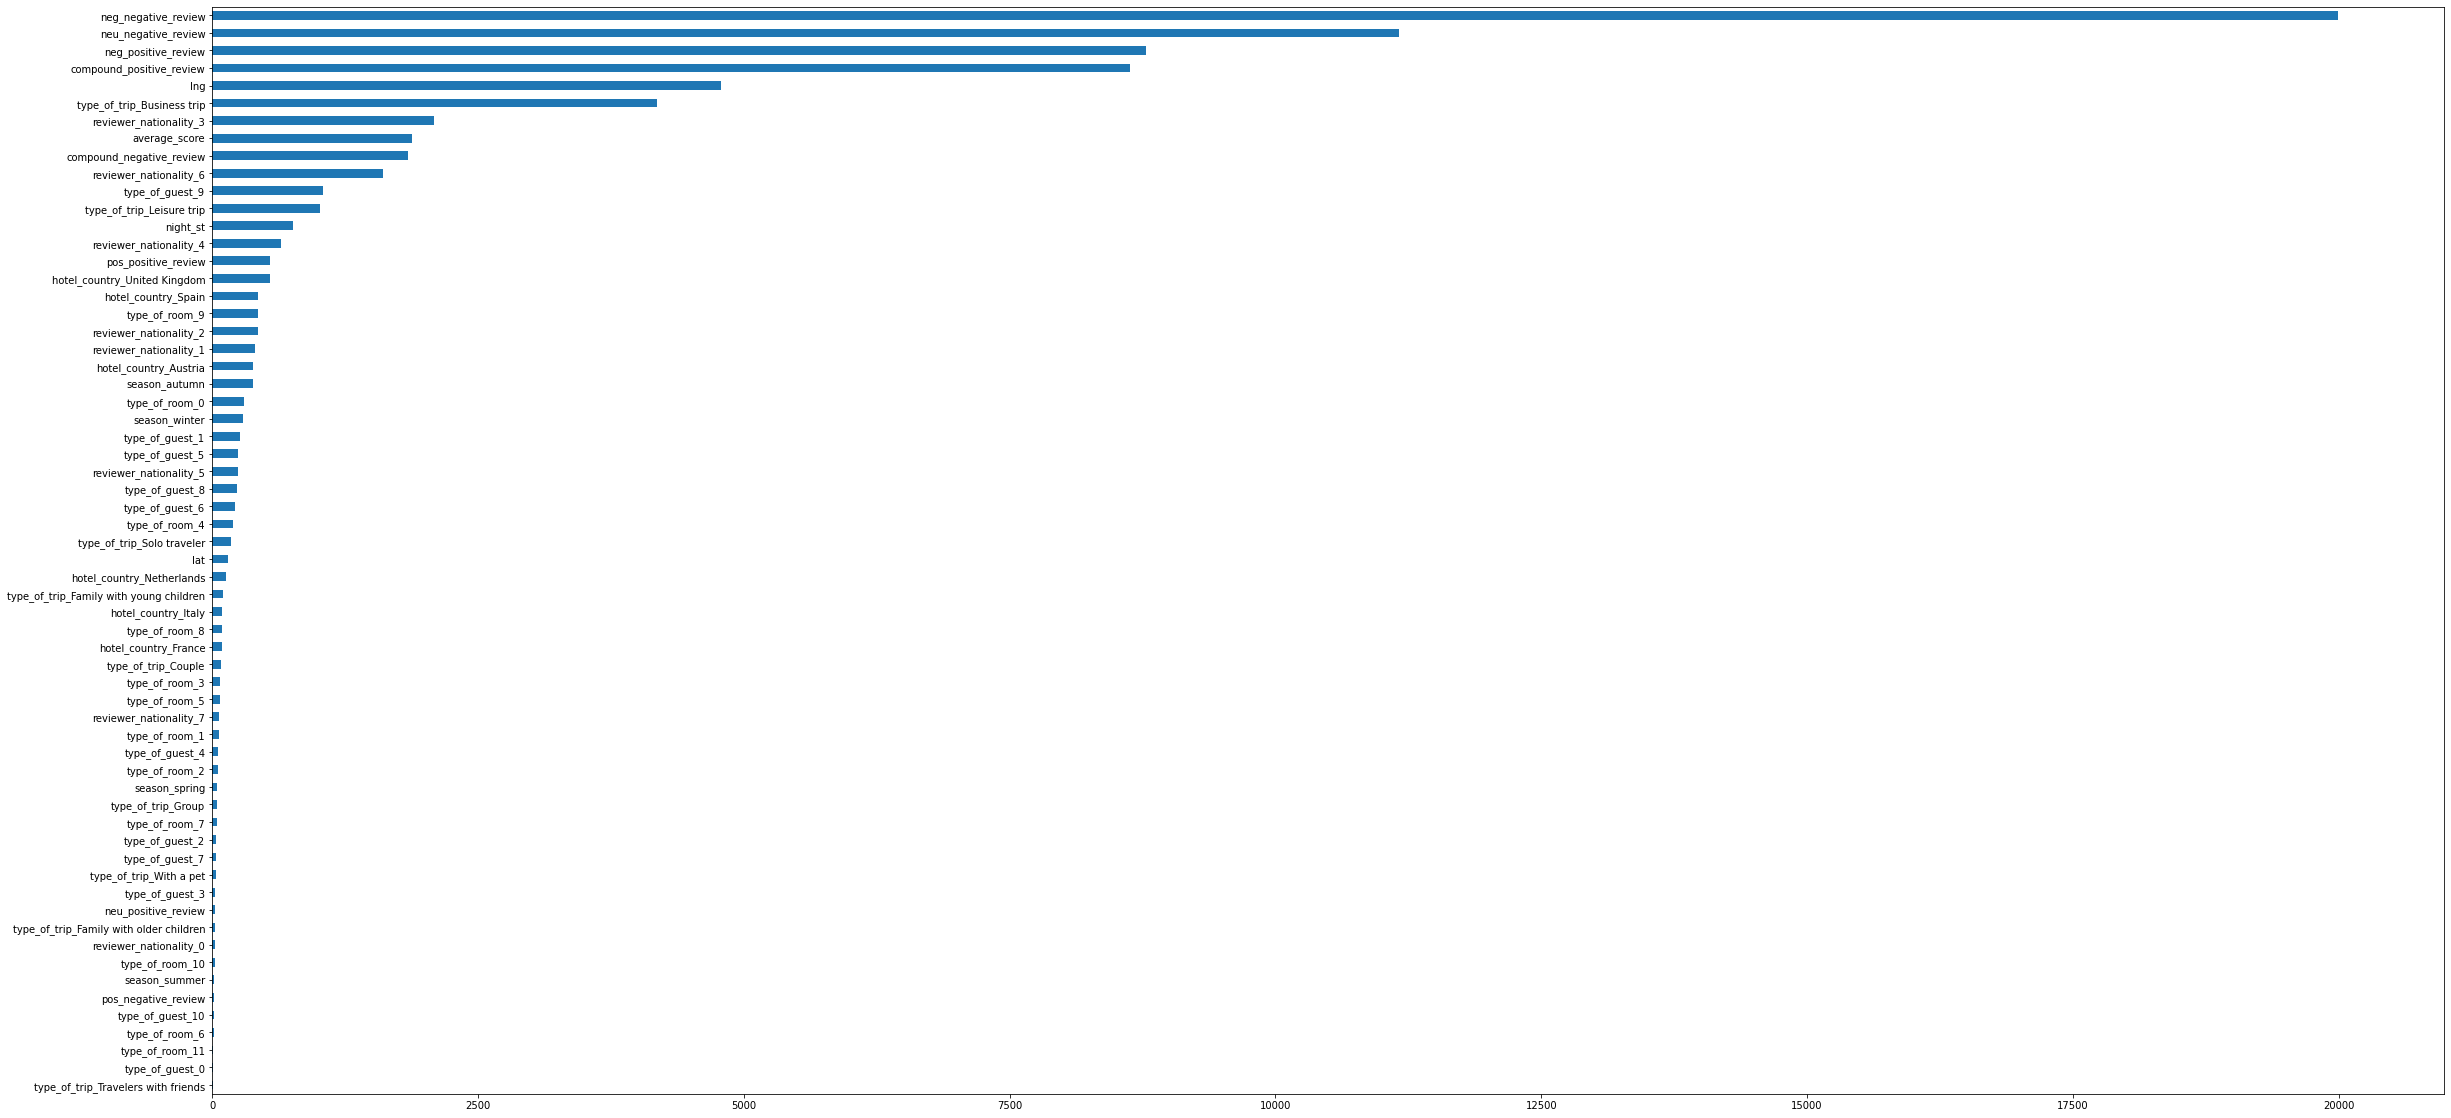

In [45]:
y=y.astype('int')
cat_col=['average_score', 'lat', 'lng', 'hotel_country_Italy','hotel_country_Netherlands', 'hotel_country_Spain', 'hotel_country_United Kingdom', 'hotel_country_France', 'hotel_country_Austria', 'season_summer', 'season_winter', 'season_autumn', 'season_spring', 'type_of_trip_Leisure trip', 'type_of_trip_Business trip', 'type_of_trip_Group', 'type_of_trip_Couple', 'type_of_trip_With a pet', 'type_of_trip_Family with young children', 'type_of_trip_Solo traveler', 'type_of_trip_Family with older children', 'type_of_trip_Travelers with friends', 'reviewer_nationality_0', 'reviewer_nationality_1', 'reviewer_nationality_2', 'reviewer_nationality_3', 'reviewer_nationality_4', 'reviewer_nationality_5', 'reviewer_nationality_6', 'reviewer_nationality_7', 'type_of_room_0', 'type_of_room_1', 'type_of_room_2', 'type_of_room_3', 'type_of_room_4', 'type_of_room_5', 'type_of_room_6', 'type_of_room_7', 'type_of_room_8', 'type_of_room_9', 'type_of_room_10', 'type_of_room_11', 'type_of_guest_0', 'type_of_guest_1', 'type_of_guest_2', 'type_of_guest_3', 'type_of_guest_4', 'type_of_guest_5', 'type_of_guest_6', 'type_of_guest_7', 'type_of_guest_8', 'type_of_guest_9', 'type_of_guest_10', 'night_st', 'neg_negative_review', 'neu_negative_review', 'pos_negative_review', 'compound_negative_review', 'neg_positive_review', 'neu_positive_review', 'pos_positive_review', 'compound_positive_review']
...
from sklearn.feature_selection import chi2 

imp_cat = pd.Series(chi2(X[cat_col].abs(), y)[0], index=cat_col)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh')

Оставляем только 15-20 признаков, которые имеют наибольшее значение.

There are some features we need to leave because of them importance:
* 'review_total_negative_word_counts'
*  'review_total_positive_word_counts'
*  'lng'
*  'neg_negative_review'
* 'neu_negative_review'
* 'neg_positive_review'
* 'compound_positive_review'
* 'type_of_trip_Business trip'
* 'reviewer_nationality_3'
* 'average_score'
* 'compound_negative_review'
* 'reviewer_nationality_6'
* 'type_of_guest_9'
* 'type_of_trip_Leisure trip'
* 'night_st'
* 'reviewer_nationality_4'
* 'hotel_country_United Kingdom'
* 'hotel_country_Spain'
* 'type_of_room_9'



Also we have high correlated features. So we need to delete:
neu_negative_review, hotel_country_United Kingdom, 'compound_negative_review', 'type_of_trip_Leisure trip'

We have 15 of the most important features:

* 'review_total_negative_word_counts'
*  'review_total_positive_word_counts'
*  'lng'
*  'neg_negative_review'
* 'neg_positive_review'
* 'compound_positive_review'
* 'type_of_trip_Business trip'
* 'reviewer_nationality_3'
* 'average_score'
* 'reviewer_nationality_6'
* 'type_of_guest_9'
* 'night_st'
* 'reviewer_nationality_4'
* 'hotel_country_Spain'
* 'type_of_room_9'




### 7. Data scaling

In [76]:
# import library
from sklearn import preprocessing

# save names of features
col_names = list(df_cleaned.columns)

mm_scaler = preprocessing.MinMaxScaler()

# encodind data
df_scaled = mm_scaler.fit_transform(df_cleaned)

# make scaled data  to dataframe
data_scaled = pd.DataFrame(df_scaled, columns=col_names)

In [77]:
data_scaled

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,lat,lng,sample,reviewer_score,...,type_of_guest_10,night_st,neg_negative_review,neu_negative_review,pos_negative_review,compound_negative_review,neg_positive_review,neu_positive_review,pos_positive_review,compound_positive_review
0,0.336815,0.630435,0.127451,1.000000,0.156962,0.000000,0.379772,0.566971,0.0,0.00,...,1.0,0.033333,0.129,0.747,0.125,0.472745,0.000,0.671,0.329,0.980933
1,0.227900,0.739130,0.024510,0.299212,0.000000,0.016949,0.998687,0.309263,0.0,0.00,...,0.0,0.000000,0.216,0.784,0.000,0.352089,0.379,0.000,0.621,0.667440
2,0.016785,0.673913,0.007353,0.018524,0.012658,0.039548,0.005854,0.150423,0.0,0.00,...,1.0,0.000000,0.000,1.000,0.000,0.500527,0.000,0.260,0.740,0.844388
3,0.089519,0.847826,0.000000,0.090215,0.068354,0.022599,0.374963,0.568468,0.0,0.00,...,1.0,0.000000,1.000,0.000,0.000,0.144677,0.000,0.621,0.379,0.957629
4,0.310705,0.847826,0.000000,0.279305,0.017722,0.002825,0.997323,0.312484,0.0,0.00,...,1.0,0.033333,1.000,0.000,0.000,0.144677,0.000,0.230,0.770,0.885195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,0.039537,0.826087,0.000000,0.034522,0.025316,0.025424,0.918157,0.010620,1.0,0.88,...,0.0,0.033333,1.000,0.000,0.000,0.144677,0.000,1.000,0.000,0.495939
515734,0.101082,0.695652,0.000000,0.191315,0.235443,0.000000,0.619953,0.996520,1.0,0.92,...,1.0,0.100000,1.000,0.000,0.000,0.144677,0.045,0.857,0.098,0.862346
515735,0.170086,0.347826,0.029412,0.162868,0.022785,0.056497,0.920574,0.014183,1.0,0.83,...,1.0,0.000000,0.000,1.000,0.000,0.500527,0.000,0.465,0.535,0.891652
515736,0.135770,0.630435,0.000000,0.091658,0.015190,0.076271,0.920062,0.012461,1.0,0.92,...,1.0,0.033333,1.000,0.000,0.000,0.144677,0.000,1.000,0.000,0.495939


## 8. Implementing a machine learning algorithm.

In [78]:
# Теперь выделим тестовую часть
train_data = data_scaled.query('sample == 1').drop(['sample'], axis=1)
test_data = data_scaled.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # target
X = train_data.drop(['reviewer_score'], axis=1)

In [79]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [80]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 72), (386803, 72), (386803, 71), (309442, 71), (77361, 71))

In [81]:
# import libraries:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [82]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [83]:
# Обучаем модель на тестовом наборе данных 
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.9s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.9s finished


In [84]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
# MAE
#0.9822
# 0.97833
# 0.9778
# MAPE
# 14.07
#print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))
def mape_func(y_test, y_pred):
    mape = np.mean(np.abs((y_test - y_pred)/y_test))*100
    return mape

print('mape:', mape_func(y_test, y_pred))

mape: 12.529068565669101


<AxesSubplot:>

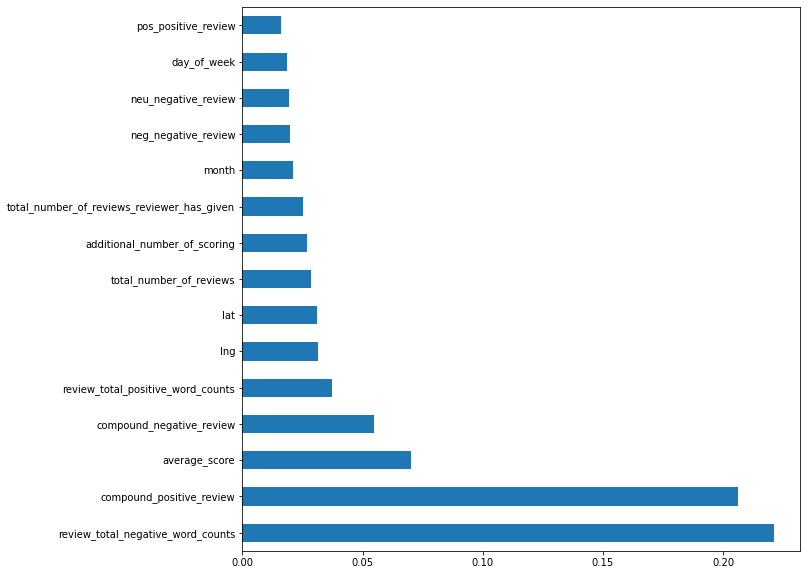

In [85]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')

## Conclusions.

Processing textual features allowed us to improve the MAPE score from 14% to 12%. We also found that the features review_total_negative_word_counts and compound_positive_review have the greatest impact on hotel ratings. To further enhance the model's performance, additional work with text features is recommended.